# Credit Card Default Prediction Using Machine Learning

## Objective
The objective of this project is to predict whether a credit card client will default on the next payment using multiple machine learning classification algorithms.

The following classification models will be compared:
- Logistic Regression
- Decision Tree Classifier
- K-Nearest Neighbors Classifier
- Naive Bayes Classifier
- Random Forest Classifier

The models will be evaluated using Accuracy, AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).

In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

## 2. Dataset Information and Initial Inspection

The dataset is inspected to understand its dimensions, feature types, target variable, missing values, duplicate records, and class distribution before preprocessing.

In [2]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Load the Default of Credit Card Clients dataset directly from UCI
credit_data = fetch_ucirepo(id=350)

# Features and target
X = credit_data.data.features
y = credit_data.data.targets

# Combine them into one DataFrame for inspection
df = pd.concat([X, y], axis=1)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


2.1 Check shape and column names

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (30000, 24)

Column Names:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


2.2 Check data types and basic information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       30000 non-null

2.3 Check missing values

In [5]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values:
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

Total Missing Values: 0


2.4 Check duplicate rows

In [6]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 35


2.5 Check target distribution

In [7]:
print("Target Class Distribution:")
print(df["Y"].value_counts())

print("\nTarget Class Distribution (%):")
print(df["Y"].value_counts(normalize=True) * 100)

Target Class Distribution:
Y
0    23364
1     6636
Name: count, dtype: int64

Target Class Distribution (%):
Y
0    77.88
1    22.12
Name: proportion, dtype: float64


2.6 Descriptive statistics

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


### 2.7 Rename Features for Interpretability

The original UCI dataset represents the predictors as X1–X23 and the target as Y. 
For better interpretability during exploratory analysis, model development, and deployment, 
the variables are renamed according to their definitions in the dataset documentation.

In [9]:
column_names = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "DEFAULT"
}

df.rename(columns=column_names, inplace=True)

print(df.columns.tolist())
df.head()

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 2.8 Inspect Categorical and Repayment Status Variables

Although all variables are stored numerically, some features represent categorical or ordinal information using integer codes. Their unique values are inspected before preprocessing to identify invalid or unusual categories.

In [10]:
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(sorted(df[col].unique()))
    print(df[col].value_counts().sort_index())


SEX
[np.int64(1), np.int64(2)]
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

PAY_0
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       9

In [12]:
# Combine uncommon/undocumented education categories into "Other"
df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Combine undocumented marriage category 0 into "Other"
df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})
print("EDUCATION:")
print(df["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE:")
print(df["MARRIAGE"].value_counts().sort_index())

EDUCATION:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


## 3. Feature Preparation

The predictors contain a mixture of continuous numerical variables, categorical variables represented using integer codes, and ordinal repayment-status variables.

The features are therefore grouped according to their meaning before model training.

In [13]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

ordinal_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

continuous_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

print("Categorical features:", len(categorical_features))
print("Ordinal features:", len(ordinal_features))
print("Continuous features:", len(continuous_features))
print("Total predictors:",
      len(categorical_features)
      + len(ordinal_features)
      + len(continuous_features))

Categorical features: 3
Ordinal features: 6
Continuous features: 14
Total predictors: 23


Step 3.1 — Separate X and y

In [14]:
X = df.drop(columns=["DEFAULT"])
y = df["DEFAULT"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


Step 3.2 — Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (24000, 23)
Test set: (6000, 23)


In [16]:
print("Original target distribution:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Original target distribution:
DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64

Training target distribution:
DEFAULT
0    77.879167
1    22.120833
Name: proportion, dtype: float64

Testing target distribution:
DEFAULT
0    77.883333
1    22.116667
Name: proportion, dtype: float64


Observation: The target variable is moderately imbalanced, with approximately 77.88% non-default and 22.12% default cases. A stratified train-test split was therefore used to preserve the original class distribution in both subsets. The resulting training (77.88%/22.12%) and testing (77.88%/22.12%) distributions confirm that stratification was successful.

## 4. Model Development and Evaluation

The classification models are trained using the same training dataset and evaluated on the same test dataset for a fair comparison.

The following evaluation metrics are used as required:
- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

### 4.1 Logistic Regression

Logistic Regression is used as the first classification model. Since the dataset contains features measured on substantially different scales, continuous numerical features are standardized. Categorical features are one-hot encoded, while the ordinal repayment-status features retain their ordered numerical representation.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocessing for Logistic Regression
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

# Create Logistic Regression pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Train the model
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

#### 4.1.1 Model Prediction

In [18]:
# Predict class labels
y_pred_lr = lr_pipeline.predict(X_test)

# Predict probability of the positive class (DEFAULT = 1)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


#### 4.1.2 Logistic Regression Evaluation Metrics

In [20]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_mcc = matthews_corrcoef(y_test, y_pred_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"AUC Score : {lr_auc:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"MCC Score : {lr_mcc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy  : 0.8088
AUC Score : 0.7100
Precision : 0.6915
Recall    : 0.2449
F1 Score  : 0.3617
MCC Score : 0.3304


#### 4.1.3 Confusion Matrix and Classification Report

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[4528  145]
 [1002  325]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



#### 4.1.4 Interpretation

The Logistic Regression model achieved an accuracy of 80.88% and an AUC score of 0.7100, indicating moderate overall discrimination between default and non-default customers.

However, the dataset is imbalanced, with approximately 77.88% non-default and 22.12% default observations. Therefore, accuracy alone does not provide a complete assessment of model performance.

For the default class (DEFAULT = 1), the model achieved a precision of 69.15% but a relatively low recall of 24.49%. The confusion matrix shows that the model correctly identified 325 defaulters but failed to identify 1002 actual defaulters. This indicates that the model is conservative in predicting the default class.

The F1 score of 0.3617 reflects the imbalance between precision and recall, while the MCC score of 0.3304 indicates a moderate relationship between the predicted and actual classes.

Overall, Logistic Regression provides a useful baseline model, but its relatively low recall suggests that it has difficulty identifying a large proportion of customers who actually default.

### 4.2 Decision Tree Classifier

A Decision Tree Classifier is trained as the second classification model. Decision Trees recursively split the feature space based on conditions that improve class separation.

Unlike Logistic Regression, Decision Trees are not sensitive to differences in feature scale. Therefore, feature standardization is not required for this model.

In [22]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

dt_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### 4.2.1 Model Prediction

In [23]:
# Predict class labels
y_pred_dt = dt_model.predict(X_test)

# Predict probability of the positive class (DEFAULT = 1)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


#### 4.2.2 Decision Tree Evaluation Metrics

In [24]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_mcc = matthews_corrcoef(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"AUC Score : {dt_auc:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")
print(f"MCC Score : {dt_mcc:.4f}")

Decision Tree Performance
-------------------------
Accuracy  : 0.7195
AUC Score : 0.6099
Precision : 0.3766
Recall    : 0.4092
F1 Score  : 0.3922
MCC Score : 0.2106


#### 4.2.3 Confusion Matrix and Classification Report

In [25]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Confusion Matrix:
[[3774  899]
 [ 784  543]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.38      0.41      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000



#### 4.2.4 Interpretation

The Decision Tree achieved an accuracy of 71.95% and an AUC score of 0.6099. Compared with Logistic Regression, it identified a larger proportion of actual defaulters, achieving a recall of 40.92%. The confusion matrix shows that 543 actual defaulters were correctly identified, while 784 were missed.

However, this improvement in recall was accompanied by a substantial increase in false-positive predictions. The model incorrectly classified 899 non-defaulters as defaulters, resulting in a relatively low precision of 37.66%.

The F1 score of 0.3922 is slightly higher than that of Logistic Regression because of the improved recall, but the MCC score of 0.2106 is lower. Overall, the Decision Tree detects more default cases but provides weaker overall discrimination and produces considerably more false positives than Logistic Regression.

### 4.3 K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a distance-based classification algorithm that predicts the class of a sample based on the classes of its nearest neighbors.

Since KNN relies on distance calculations, differences in feature scales can strongly influence its predictions. Therefore, continuous numerical features are standardized, categorical features are one-hot encoded, and ordinal repayment-status features retain their numerical representation.

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

# Train the model
knn_pipeline.fit(X_train, y_train)

knn_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

#### 4.3.1 Model Prediction

In [27]:
# Predict class labels
y_pred_knn = knn_pipeline.predict(X_test)

# Predict probability of the positive class (DEFAULT = 1)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


#### 4.3.2 KNN Evaluation Metrics

In [28]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_mcc = matthews_corrcoef(y_test, y_pred_knn)

print("K-Nearest Neighbors Performance")
print("--------------------------------")
print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"AUC Score : {knn_auc:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1 Score  : {knn_f1:.4f}")
print(f"MCC Score : {knn_mcc:.4f}")

K-Nearest Neighbors Performance
--------------------------------
Accuracy  : 0.7950
AUC Score : 0.7045
Precision : 0.5566
Recall    : 0.3595
F1 Score  : 0.4368
MCC Score : 0.3299


#### 4.3.3 Confusion Matrix and Classification Report

In [29]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Confusion Matrix:")
print(cm_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

Confusion Matrix:
[[4293  380]
 [ 850  477]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.56      0.36      0.44      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.64      0.66      6000
weighted avg       0.77      0.80      0.78      6000



#### 4.3.4 Interpretation

The K-Nearest Neighbors model achieved an accuracy of 79.50% and an AUC score of 0.7045, indicating moderate discriminatory ability.

For the default class, KNN achieved a precision of 55.66% and a recall of 35.95%. The confusion matrix shows that the model correctly identified 477 actual defaulters while missing 850 defaulters. It also incorrectly classified 380 non-defaulters as defaulters.

Compared with Logistic Regression, KNN provides substantially higher recall and F1 score, although its accuracy and precision are lower. Compared with the Decision Tree, KNN achieves better accuracy, AUC, precision, F1 score, and MCC, while the Decision Tree has slightly higher recall.

The F1 score of 0.4368 is the highest among the models evaluated so far, while the MCC score of 0.3299 is almost identical to Logistic Regression. Overall, KNN currently provides a better balance between identifying default cases and maintaining reasonable overall classification performance.

### 4.4 Naive Bayes Classifier

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. It assumes that the features are conditionally independent given the target class and models numerical features using Gaussian distributions.

The model is trained on the preprocessed feature representation and evaluated using the same train-test split used for the previous classifiers.

In [30]:
from sklearn.naive_bayes import GaussianNB

nb_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("classifier", GaussianNB())
    ]
)

# Train the model
nb_pipeline.fit(X_train, y_train)

nb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

#### 4.4.1 Model Prediction

In [32]:
# Predict class labels
y_pred_nb = nb_pipeline.predict(X_test)

# Predict probability of the positive class (DEFAULT = 1)
y_prob_nb = nb_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


#### 4.4.2 Naive Bayes Evaluation Metrics

In [33]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_prob_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_mcc = matthews_corrcoef(y_test, y_pred_nb)

print("Naive Bayes Performance")
print("-----------------------")
print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"AUC Score : {nb_auc:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1 Score  : {nb_f1:.4f}")
print(f"MCC Score : {nb_mcc:.4f}")

Naive Bayes Performance
-----------------------
Accuracy  : 0.6607
AUC Score : 0.7248
Precision : 0.3590
Recall    : 0.6805
F1 Score  : 0.4701
MCC Score : 0.2822


#### 4.4.3 Confusion Matrix and Classification Report

In [34]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Confusion Matrix:
[[3061 1612]
 [ 424  903]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.75      4673
           1       0.36      0.68      0.47      1327

    accuracy                           0.66      6000
   macro avg       0.62      0.67      0.61      6000
weighted avg       0.76      0.66      0.69      6000



#### 4.4.4 Interpretation

The Gaussian Naive Bayes model achieved an accuracy of 66.07% and an AUC score of 0.7248.

Although its overall accuracy and precision are lower than the previously evaluated models, Naive Bayes achieved a recall of 68.05% for the default class, which is the highest recall observed so far. The confusion matrix shows that the model correctly identified 903 actual defaulters while missing 424.

However, it also produced 1,612 false-positive predictions, resulting in a relatively low precision of 35.90%. The F1 score of 0.4701 reflects a better balance between precision and recall than some earlier models, while the MCC score of 0.2822 indicates moderate overall classification agreement.

Overall, Naive Bayes is effective at identifying a larger proportion of actual defaulters, but this comes at the cost of many false-positive predictions and lower overall accuracy.

### 4.5 Support Vector Machine (SVM)

Support Vector Machine is a supervised learning algorithm that identifies a decision boundary with the maximum margin between classes. An RBF kernel is used to allow nonlinear decision boundaries.

Since SVM is sensitive to feature scales, continuous numerical features are standardized before model training. Categorical variables are one-hot encoded using the preprocessing pipeline.

In [35]:
from sklearn.svm import SVC

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("classifier", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=42
        ))
    ]
)

svm_pipeline.fit(X_train, y_train)

svm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

#### 4.5.1 Model Prediction

In [36]:
# Predict class labels
y_pred_svm = svm_pipeline.predict(X_test)

# Obtain decision scores for ROC-AUC calculation
y_score_svm = svm_pipeline.decision_function(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


#### 4.5.2 SVM Evaluation Metrics

In [37]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_score_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_mcc = matthews_corrcoef(y_test, y_pred_svm)

print("Support Vector Machine Performance")
print("----------------------------------")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"AUC Score : {svm_auc:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1 Score  : {svm_f1:.4f}")
print(f"MCC Score : {svm_mcc:.4f}")

Support Vector Machine Performance
----------------------------------
Accuracy  : 0.8153
AUC Score : 0.7199
Precision : 0.6603
Recall    : 0.3399
F1 Score  : 0.4488
MCC Score : 0.3792


#### 4.5.3 Confusion Matrix and Classification Report

In [38]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Confusion Matrix:
[[4441  232]
 [ 876  451]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



#### 4.5.4 Interpretation

The Support Vector Machine model achieved an accuracy of 81.53% and an AUC score of 0.7199.

For the default class, SVM achieved a precision of 66.03% and a recall of 33.99%. The confusion matrix shows that 451 actual defaulters were correctly identified while 876 were missed. Only 232 non-defaulters were incorrectly classified as defaulters.

The F1 score of 0.4488 and MCC score of 0.3792 indicate a better overall balance between the two classes than several of the previously evaluated models. SVM currently provides the highest accuracy and MCC among the models evaluated so far.

However, its recall remains relatively low, indicating that a considerable number of actual default cases are still not detected.

Overall, SVM provides strong overall classification performance with relatively few false-positive predictions, but its ability to identify all actual defaulters remains limited.

### 4.6 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple Decision Trees. Each tree is trained on a different bootstrap sample of the training data and considers a random subset of features while splitting nodes.

The final classification is obtained by aggregating the predictions of the individual trees. Random Forest generally reduces the variance and overfitting associated with a single Decision Tree.

Since tree-based models are not sensitive to feature scale, feature standardization is not required.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

rf_model

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

#### 4.6.1 Model Prediction

In [44]:
# Predict class labels
y_pred_rf = rf_model.predict(X_test)

# Predict probability of the positive class (DEFAULT = 1)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


#### 4.6.2 Random Forest Evaluation Metrics

In [45]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_mcc = matthews_corrcoef(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"AUC Score : {rf_auc:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"MCC Score : {rf_mcc:.4f}")

Random Forest Performance
-------------------------
Accuracy  : 0.8142
AUC Score : 0.7572
Precision : 0.6429
Recall    : 0.3595
F1 Score  : 0.4611
MCC Score : 0.3817


#### 4.6.3 Confusion Matrix and Classification Report

In [46]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[4408  265]
 [ 850  477]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000



#### 4.6.4 Interpretation

The Random Forest classifier achieved an accuracy of 81.42% and an AUC score of 0.7572. The AUC is the highest observed among the models evaluated so far, indicating better ability to distinguish between default and non-default customers across different classification thresholds.

For the default class, the model achieved a precision of 64.29% and a recall of 35.95%. From the confusion matrix, Random Forest correctly identified 477 actual defaulters, while 850 defaulters were incorrectly classified as non-defaulters. It produced 265 false-positive predictions.

The model obtained an F1 score of 0.4611 and an MCC score of 0.3817. Compared with the individual Decision Tree, Random Forest provides substantially better overall predictive performance, demonstrating the benefit of combining multiple trees through ensemble learning.

Although SVM achieved a marginally higher accuracy and precision, Random Forest achieved better AUC, recall, F1 score, and MCC. Therefore, among the models evaluated so far, Random Forest provides the strongest overall balance of predictive performance. However, the relatively low recall indicates that many actual default cases are still missed.

## 5. Model Performance Comparison

The performance of all classification models is compared using Accuracy, AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC). Considering multiple metrics is particularly important because the target variable is imbalanced, with fewer customers belonging to the default class.

In [47]:
# Create comparison table for all models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "K-Nearest Neighbors",
        "Naive Bayes",
        "Support Vector Machine",
        "Random Forest"
    ],
    
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        knn_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ],
    
    "AUC": [
        lr_auc,
        dt_auc,
        knn_auc,
        nb_auc,
        svm_auc,
        rf_auc
    ],
    
    "Precision": [
        lr_precision,
        dt_precision,
        knn_precision,
        nb_precision,
        svm_precision,
        rf_precision
    ],
    
    "Recall": [
        lr_recall,
        dt_recall,
        knn_recall,
        nb_recall,
        svm_recall,
        rf_recall
    ],
    
    "F1 Score": [
        lr_f1,
        dt_f1,
        knn_f1,
        nb_f1,
        svm_f1,
        rf_f1
    ],
    
    "MCC": [
        lr_mcc,
        dt_mcc,
        knn_mcc,
        nb_mcc,
        svm_mcc,
        rf_mcc
    ]
})

model_comparison.round(4)

,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8088,0.7100,0.6915,0.2449,0.3617,0.3304
1,Decision Tree,0.7195,0.6099,0.3766,0.4092,0.3922,0.2106
2,K-Nearest Neighbors,0.7950,0.7045,0.5566,0.3595,0.4368,0.3299
3,Naive Bayes,0.6607,0.7248,0.3590,0.6805,0.4701,0.2822
4,Support Vector Machine,0.8153,0.7199,0.6603,0.3399,0.4488,0.3792
5,Random Forest,0.8142,0.7572,0.6429,0.3595,0.4611,0.3817


### 5.1 Performance Comparison Visualization

The following visualization compares all six evaluation metrics across the classification models. This provides a clearer view of the trade-offs between overall classification performance and the ability to identify default cases.

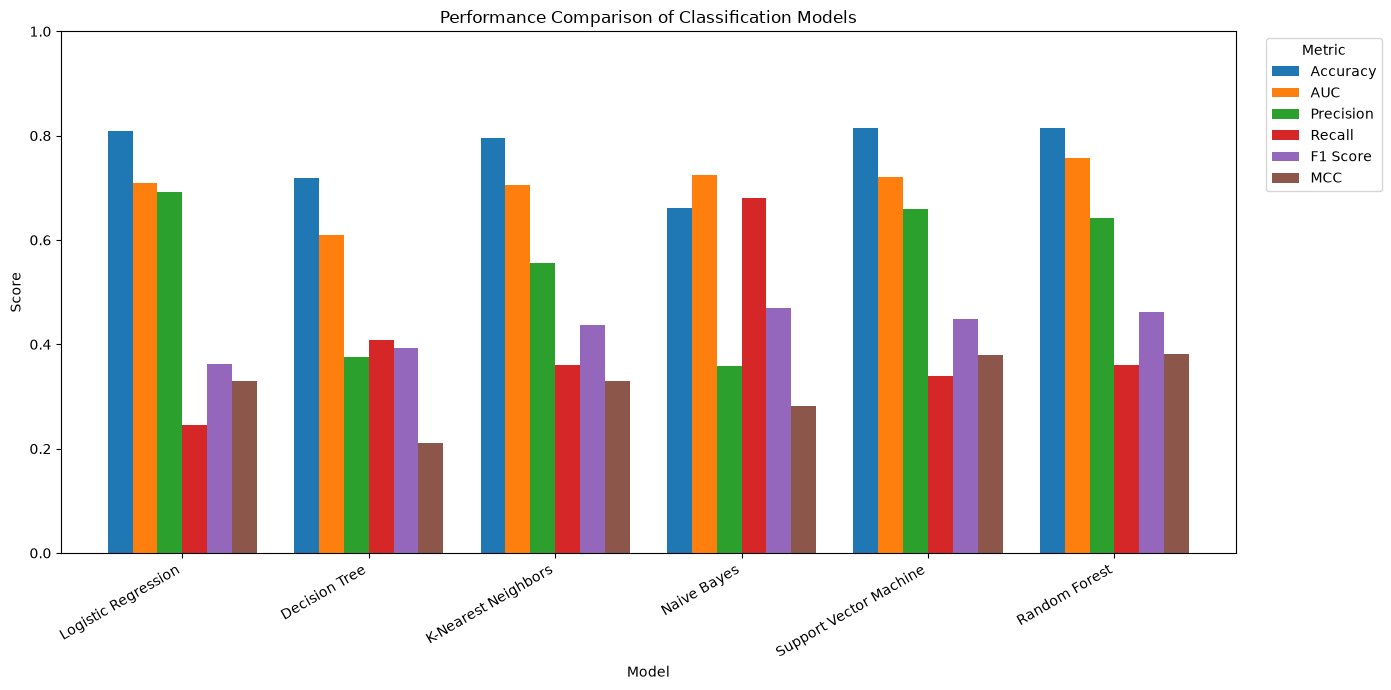

In [48]:
import matplotlib.pyplot as plt

# Set model names as index for plotting
comparison_plot = model_comparison.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title("Performance Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.2 Overall Model Comparison and Interpretation

The models demonstrate different trade-offs across the evaluation metrics.

Support Vector Machine achieved the highest accuracy (81.53%), while Logistic Regression achieved the highest precision (69.15%). However, both models showed relatively low recall for the default class, indicating that many actual defaulters were not detected.

Naive Bayes achieved the highest recall (68.05%) and F1 score (0.4701). This indicates that it identifies a substantially larger proportion of actual defaulters. However, its low precision (35.90%) and overall accuracy (66.07%) show that this improvement in recall is accompanied by a large number of false-positive predictions.

Random Forest achieved the highest AUC (0.7572) and MCC (0.3817), while also maintaining an accuracy of 81.42%, precision of 64.29%, recall of 35.95%, and F1 score of 0.4611. Its AUC indicates the strongest overall discrimination between default and non-default customers, while its MCC indicates the best overall agreement between predicted and actual classes among the evaluated models.

Therefore, considering the complete set of evaluation metrics rather than accuracy alone, Random Forest provides the strongest overall baseline performance. Nevertheless, Naive Bayes may be preferable when identifying as many potential defaulters as possible is prioritized over false-positive predictions.

### 5.3 ROC Curve Comparison

Receiver Operating Characteristic (ROC) curves are used to compare the ability of the classification models to distinguish between default and non-default customers across different classification thresholds.

The Area Under the ROC Curve (AUC) summarizes this discrimination ability, where a larger AUC indicates better overall class separation.

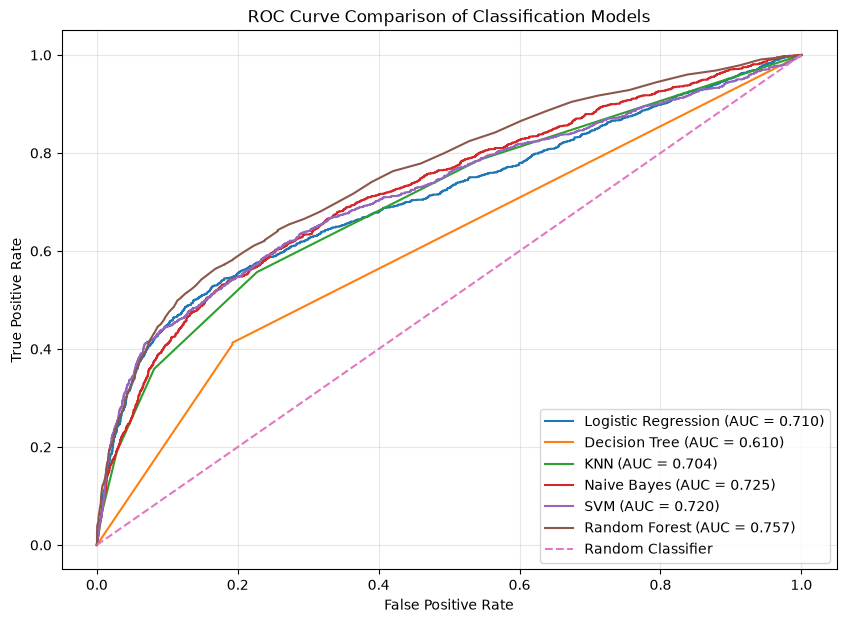

In [49]:
from sklearn.metrics import roc_curve

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

# SVM uses decision_function scores
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 7))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {lr_auc:.3f})")

plt.plot(fpr_dt, tpr_dt,
         label=f"Decision Tree (AUC = {dt_auc:.3f})")

plt.plot(fpr_knn, tpr_knn,
         label=f"KNN (AUC = {knn_auc:.3f})")

plt.plot(fpr_nb, tpr_nb,
         label=f"Naive Bayes (AUC = {nb_auc:.3f})")

plt.plot(fpr_svm, tpr_svm,
         label=f"SVM (AUC = {svm_auc:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {rf_auc:.3f})")

# Random-classifier reference line
plt.plot([0, 1], [0, 1], "--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### 5.3.1 ROC Curve Interpretation

The ROC curve comparison shows that all six models perform better than a random classifier, as their AUC values are greater than 0.5.

Random Forest achieved the highest AUC of 0.7572, indicating the strongest overall ability to discriminate between default and non-default customers across different classification thresholds.

Naive Bayes achieved the second-highest AUC of 0.7248, followed by SVM (0.7199), Logistic Regression (0.7100), KNN (0.7045), and Decision Tree (0.6099).

The comparatively lower AUC of the individual Decision Tree suggests weaker generalization, whereas the improvement obtained by Random Forest demonstrates the benefit of combining multiple decision trees through ensemble learning.

6. Save Trained Models and Test Data

In [50]:
import os
import joblib

# Create folder for saved models
os.makedirs("model", exist_ok=True)

# Save all trained models / pipelines
joblib.dump(lr_pipeline, "model/logistic_regression.pkl")
joblib.dump(dt_model, "model/decision_tree.pkl")
joblib.dump(knn_pipeline, "model/knn.pkl")
joblib.dump(nb_pipeline, "model/naive_bayes.pkl")
joblib.dump(svm_pipeline, "model/svm.pkl")
joblib.dump(rf_model, "model/random_forest.pkl")

print("All trained models saved successfully.")

All trained models saved successfully.


6.1 Save Test Data:

In [51]:
# Combine test features and target
test_data = X_test.copy()
test_data["DEFAULT"] = y_test.values

# Save test data for Streamlit application
test_data.to_csv("test_data.csv", index=False)

print("Test data saved successfully.")
print("Test data shape:", test_data.shape)

test_data.head()

Test data saved successfully.
Test data shape: (6000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
6907,50000,1,2,2,46,-1,-1,-1,-1,0,...,2650,3320,2764,26060,0,3472,2320,1764,2841,0
24575,150000,1,1,1,31,-1,-1,-2,-2,-2,...,0,0,11694,0,0,0,0,11694,30000,0
26766,50000,1,2,2,25,0,0,0,0,0,...,49949,50479,50702,1800,1844,2200,2000,1800,2038,0
2156,290000,2,1,2,25,0,0,0,0,0,...,248801,241983,230925,15000,10500,10000,15000,7844,23333,1
3179,500000,2,2,1,27,-2,-2,-2,-2,-2,...,10000,10000,10000,9983,13587,10000,10000,10000,25304,0


6.2 Verify Saved Models

In [52]:
# Reload saved Random Forest model
loaded_rf = joblib.load("model/random_forest.pkl")

# Reload saved test data
loaded_test_data = pd.read_csv("test_data.csv")

# Separate features and target
X_test_loaded = loaded_test_data.drop(columns=["DEFAULT"])
y_test_loaded = loaded_test_data["DEFAULT"]

# Generate predictions using the reloaded model
y_pred_loaded = loaded_rf.predict(X_test_loaded)

# Verify performance
loaded_accuracy = accuracy_score(y_test_loaded, y_pred_loaded)
loaded_auc = roc_auc_score(
    y_test_loaded,
    loaded_rf.predict_proba(X_test_loaded)[:, 1]
)

print("Saved Random Forest loaded successfully.")
print(f"Accuracy: {loaded_accuracy:.4f}")
print(f"AUC Score: {loaded_auc:.4f}")

Saved Random Forest loaded successfully.
Accuracy: 0.8142
AUC Score: 0.7572
